<a href="https://colab.research.google.com/github/atharva-soni/PublicHealthDS_Diabetes/blob/main/Copy_of_PublicHealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team: Public Health — CDC BRFSS
## End-to-End Data Investigation: Who Gets Left Out of Health Care?

**Dataset:** CDC Behavioral Risk Factor Surveillance System (BRFSS) — 86,481 rows × 27 columns
**Source:** [data.cdc.gov, dataset `d2rk-yvas`](https://data.cdc.gov/resource/d2rk-yvas.csv)

This notebook is your **full Capstone pipeline, start to finish**:

| Stage | HCD Phase | What you'll do |
|---|---|---|
| 1. Assess | Empathize/Define | Audit the raw dataset for quality problems |
| 2. Clean | Define | Build a documented, justified cleaning pipeline |
| 3. Visualize | Define | Build 4 publication-quality charts |
| 4. Story | Define | Write a 150-word Data Brief |
| 5. Problem Statement | Define | Write your formal Data Problem Statement |
| 6. Baseline model | Prototype | Build the "dumb model to beat" |
| 7. Compare ML models | Prototype | Train and compare 3 real classifiers |
| 8. Fairness check | Prototype | Test whether your model fails some groups more than others |

**Important note about this data:** BRFSS is **not** one row per person. Each row is a *summary statistic* — the percentage of one demographic subgroup, in one state, in one year, who gave a particular answer to a survey question. Keep asking: *what group of real people does this one row represent?*


## 📚 Vocabulary for This Notebook

| Term | Plain-English Meaning |
|---|---|
| **Long format** | Each row is one (question × subgroup × state × year) combination, not one person |
| **`Break_Out`** | The specific subgroup a row describes (e.g., "Black, non-Hispanic", "$50,000+") |
| **`Break_Out_Category`** | The *type* of subgroup (e.g., Race/Ethnicity, Income, Age, Sex, or "Overall") |
| **`Data_value`** | The percentage of that subgroup who gave that answer |
| **`Sample_Size`** | How many survey respondents that percentage is based on — smaller samples are less reliable |
| **Baseline model** | The simplest possible prediction — the model you have to *beat* to prove your real model adds value |
| **Fairness check** | Testing whether a model performs equally well across different demographic groups, not just on average |


## Load the Dataset


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Backup option if the GitHub link isn't ready: load directly from the CDC Socrata API
# url = "https://data.cdc.gov/resource/d2rk-yvas.csv?$limit=90000"
# df = pd.read_csv(url)

print('Shape:', df.shape)
df.head()


Shape: (86481, 27)


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
0,2023,AK,Alaska,Tobacco Use,Smoker Status,Four Level Smoking Status (variable calculated...,Smoke everyday,Overall,Overall,526,...,NaN,BRFSS,CLASS17,TOPIC55,2,BO1,CAT1,_SMOKER3,RESP068,"(64.84507995700051, -147.72205903599973)"
1,2023,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,No,Overall,Overall,2412,...,NaN,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY6,RESP054,"(64.84507995700051, -147.72205903599973)"
2,2023,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,Yes,Overall,Overall,2824,...,NaN,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY6,RESP046,"(64.84507995700051, -147.72205903599973)"
3,2023,AK,Alaska,Alcohol Consumption,Binge Drinking,Binge drinkers (males having five or more drin...,No,Overall,Overall,4430,...,NaN,BRFSS,CLASS01,TOPIC07,2,BO1,CAT1,_RFBING6,RESP054,"(64.84507995700051, -147.72205903599973)"
4,2023,AK,Alaska,Alcohol Consumption,Binge Drinking,Binge drinkers (males having five or more drin...,Yes,Overall,Overall,761,...,NaN,BRFSS,CLASS01,TOPIC07,2,BO1,CAT1,_RFBING6,RESP046,"(64.84507995700051, -147.72205903599973)"


## Step 1 — Assess

**Before you touch this data: what question are we investigating?**

> **Our question:** Who is being left out of health care access — and does that gap fall along lines of race, income, age, or geography?
>
> We'll use the `Health Care Access/Coverage` questions in this dataset — like whether someone has a personal doctor, or when they last had a checkup.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86481 entries, 0 to 86480
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        86481 non-null  int64  
 1   Locationabbr                86481 non-null  object 
 2   Locationdesc                86481 non-null  object 
 3   Class                       86481 non-null  object 
 4   Topic                       86481 non-null  object 
 5   Question                    86481 non-null  object 
 6   Response                    86481 non-null  object 
 7   Break_Out                   86481 non-null  object 
 8   Break_Out_Category          86481 non-null  object 
 9   Sample_Size                 86481 non-null  int64  
 10  Data_value                  85876 non-null  float64
 11  Confidence_limit_Low        85876 non-null  float64
 12  Confidence_limit_High       85876 non-null  float64
 13  Display_order               864

In [ ]:
# Only numeric columns show up here — Data_value, Sample_Size, Year, etc.
df.describe()


,Year,Sample_Size,Data_value,Confidence_limit_Low,Confidence_limit_High,Display_order,LocationID
count,86481.000000,86481.000000,85876.000000,85876.000000,85876.000000,86481.000000,86481.000000
mean,2017.685399,3195.528220,42.718594,41.426599,44.010271,1051.272002,30.795412
std,3.888165,3730.550618,34.916068,34.848479,35.004507,1433.031397,17.587686
min,2011.000000,1.000000,0.100000,0.000000,0.100000,1.000000,1.000000
25%,2014.000000,611.000000,9.800000,8.700000,10.800000,1.000000,17.000000
50%,2018.000000,1731.000000,30.500000,28.500000,32.300000,3.000000,30.000000
75%,2021.000000,4687.000000,79.900000,78.300000,81.500000,2225.000000,45.000000
max,2024.000000,42176.000000,100.000000,100.000000,102.700000,4439.000000,78.000000


In [ ]:
df.isnull().sum()


,0
Year,0
Locationabbr,0
Locationdesc,0
Class,0
Topic,0
Question,0
Response,0
Break_Out,0
Break_Out_Category,0
Sample_Size,0


In [ ]:
# Remember: this is a LONG table. One "topic" can mean many rows.
# Let's see what's actually in the columns we care about most.
print(df['Class'].unique())
print()
print(df[df['Class'] == 'Health Care Access/Coverage']['Question'].unique())


['Colorectal Cancer Screening' 'Chronic Health Indicators' 'Health Status'
 'HIV-AIDS' 'Immunization' 'Demographics' 'Oral Health'
 'Overweight and Obesity (BMI)' 'Physical Activity' 'Tobacco Use'
 'Alcohol Consumption' 'Cholesterol Awareness'
 'Health Care Access/Coverage' 'Hypertension Awareness' 'Injury'
 'Prostate Cancer' "Women's Health" 'Fruits and Vegetables'
 'E-Cigarette Use' 'Days of Poor Health' 'Lung Cancer Screening']

['Do you have any kind of health care coverage?'
 'Adults aged 18-64 who have any kind of health care coverage (variable calculated from one or more BRFSS questions)'
 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
 'About how long has it been since you last visited a doctor for a routine checkup?'
 'Do you have one person you think of as your personal doctor or health care provider?'
 'Was there a time in the past 12 months when you needed to see a doctor but could not because you could not afford it?

In [ ]:
# Notice: Data_value is missing for 605 rows. Data_Value_Footnote is filled in for exactly 605 rows.
# That's not a coincidence -- check it yourself:
print('Missing Data_value:', df['Data_value'].isnull().sum())
print('Rows with a footnote:', df['Data_Value_Footnote'].notnull().sum())
print()
print(df.loc[df['Data_value'].isnull(), 'Data_Value_Footnote'].value_counts())


In [ ]:
df.

Index(['Year', 'Locationabbr', 'Locationdesc', 'Class', 'Topic', 'Question',
       'Response', 'Break_Out', 'Break_Out_Category', 'Sample_Size',
       'Data_value', 'Confidence_limit_Low', 'Confidence_limit_High',
       'Display_order', 'Data_value_unit', 'Data_value_type',
       'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'DataSource',
       'ClassId', 'TopicId', 'LocationID', 'BreakoutID', 'BreakOutCategoryID',
       'QuestionID', 'RESPONSEID', 'Geolocation'],
      dtype='object')

In [ ]:
print(df[df['Topic'].str.contains('Diabetes', case=False, na=False)]['Topic'].unique())

['Diabetes']


Cramér's V: 1.000
P-value from Chi-squared test: 0.000
There is a statistically significant association between 'Topic' and 'Class'.


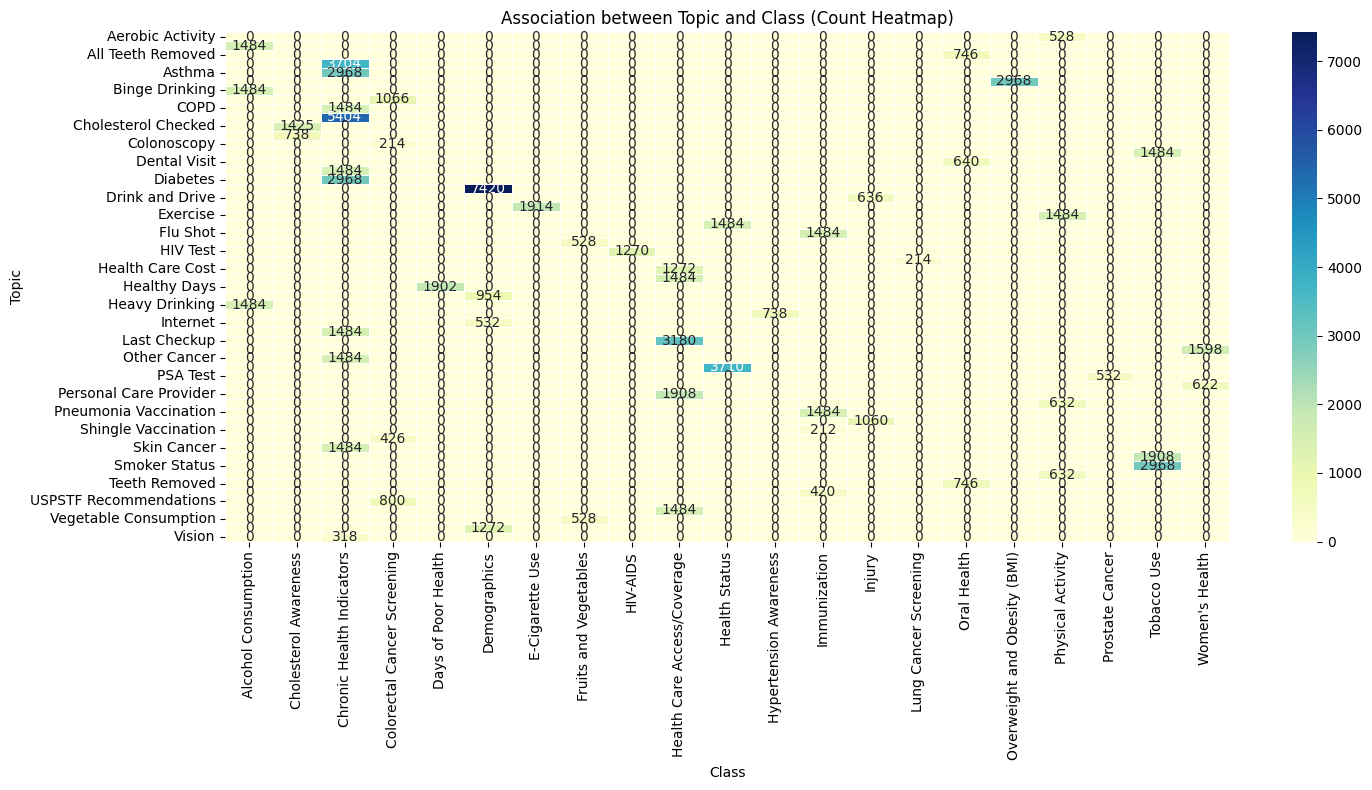

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a contingency table (cross-tabulation) of the two categorical variables
contingency_table = pd.crosstab(df["Topic"], df["Class"])

# Perform the Chi-squared test for independence
chi2, p_value, _, _ = chi2_contingency(contingency_table)

# Calculate Cramér's V
n = contingency_table.sum().sum() # Total number of observations
min_dim = min(contingency_table.shape) - 1

if min_dim == 0: # Handle cases where one dimension has only one category
    cramers_v = 0.0
else:
    cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramér's V: {cramers_v:.3f}")
print(f"P-value from Chi-squared test: {p_value:.3f}")

if p_value < 0.05:
    print("There is a statistically significant association between 'Topic' and 'Class'.")
else:
    print("There is no statistically significant association between 'Topic' and 'Class' (at alpha=0.05).")

# --- Visualization of association for categorical variables ---
# A line graph is not suitable for showing the 'correlation' between two nominal categorical variables.
# Instead, a heatmap of the contingency table can effectively visualize their association.

plt.figure(figsize=(15, 8))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Association between Topic and Class (Count Heatmap)')
plt.xlabel('Class')
plt.ylabel('Topic')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Since both 'Topic' and 'Class' are categorical variables, a standard 'correlation' line graph isn't the most appropriate visualization. The Cramér's V we calculated is a single statistic summarizing their association, not a trend over time or an ordered axis that a line graph typically displays. However, we can visualize the relationship or distribution between these two categorical variables using a heatmap of their contingency table. This will show you how frequently different topics appear within different classes.

In [ ]:
print(df[df['Topic'].str.contains('Diabetes', case=False, na=False)])

       Year Locationabbr Locationdesc                      Class     Topic  \
252    2024           AK       Alaska  Chronic Health Indicators  Diabetes   
358    2011           AL      Alabama  Chronic Health Indicators  Diabetes   
359    2011           AL      Alabama  Chronic Health Indicators  Diabetes   
360    2011           AL      Alabama  Chronic Health Indicators  Diabetes   
361    2011           AL      Alabama  Chronic Health Indicators  Diabetes   
...     ...          ...          ...                        ...       ...   
86277  2024           WI    Wisconsin  Chronic Health Indicators  Diabetes   
86392  2024           WY      Wyoming  Chronic Health Indicators  Diabetes   
86393  2024           WY      Wyoming  Chronic Health Indicators  Diabetes   
86394  2024           WY      Wyoming  Chronic Health Indicators  Diabetes   
86395  2024           WY      Wyoming  Chronic Health Indicators  Diabetes   

                                                Question  \
252

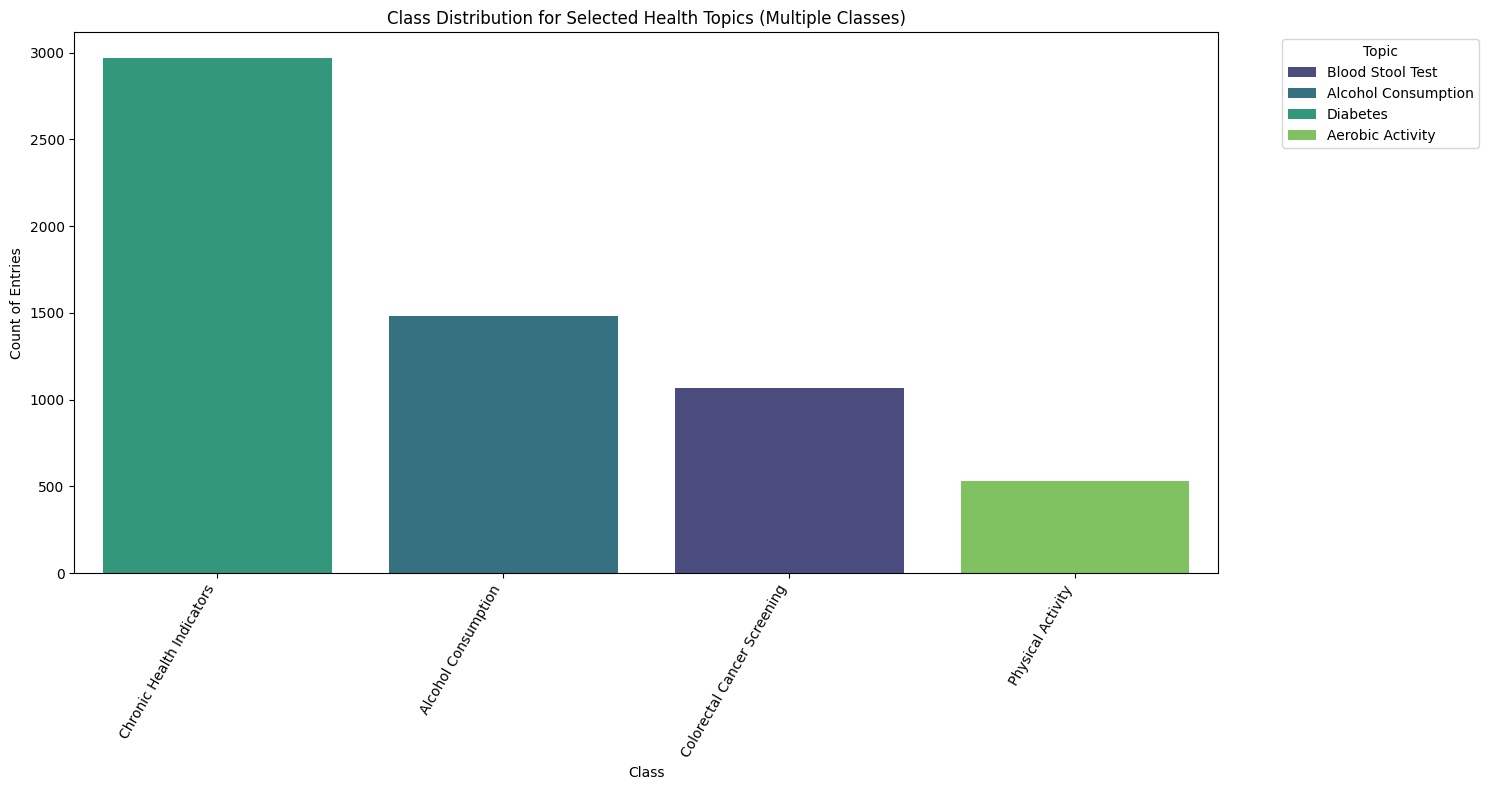

In [ ]:
selected_topics = [
    'Diabetes',
    'Alcohol Consumption',
    'Blood Stool Test',
    'Health Care Access',
    'Smoking Status',
    'Aerobic Activity'
]
filtered_data = df[df['Topic'].isin(selected_topics)]

plt.figure(figsize=(15, 8)) # Increased figure size for better readability with more classes
# Using 'Class' as x and 'Topic' as hue will show the count of each topic within each class.
# This effectively visualizes the "correlation" or association for multiple topics and classes.
sns.countplot(data=filtered_data, x='Class', hue='Topic', palette='viridis', order=filtered_data['Class'].value_counts().index)
plt.title('Class Distribution for Selected Health Topics (Multiple Classes)')
plt.xlabel('Class')
plt.ylabel('Count of Entries')
plt.xticks(rotation=60, ha='right') # Rotate labels further for more classes
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The bar chart visualizes the distribution of various health topics across different 'Class' categories. For each 'Class' on the x-axis, there are multiple bars, each representing a different 'Topic' (like Diabetes, Alcohol Consumption, etc.). The height of each bar indicates the count of entries for that specific topic within that class. This chart helps to quickly identify which topics fall under which health classes and their relative frequencies, providing insights into the associations between them.

/tmp/ipykernel_625/1511193026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_diabetes_mean, x='Class', y='Data_value', palette='viridis')


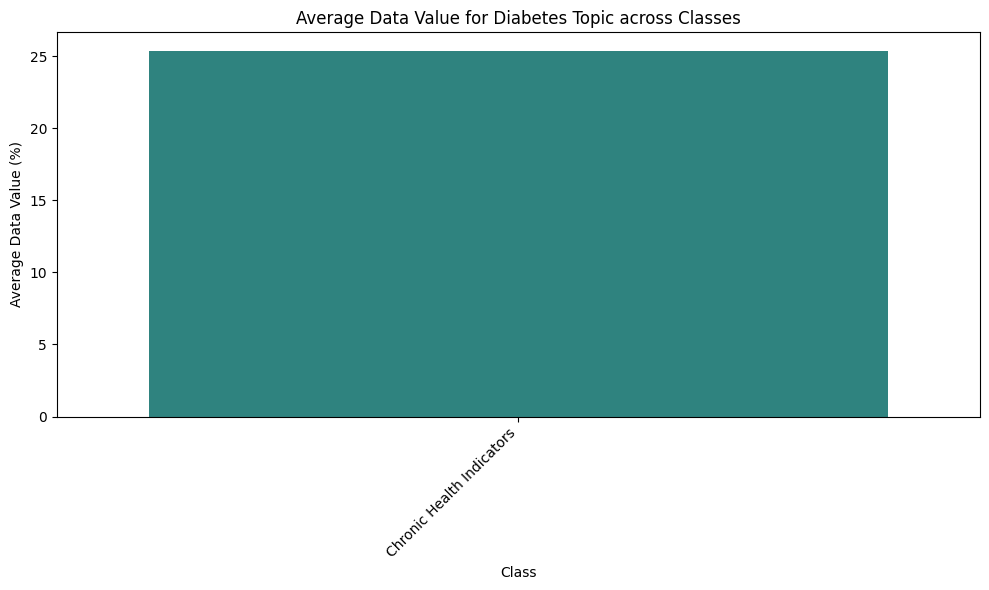

In [ ]:
diabetes_data = df[df['Topic'] == 'Diabetes']

if not diabetes_data.empty:
    # Group by 'Class' and calculate the mean 'Data_value' for 'Diabetes' topic
    class_diabetes_mean = diabetes_data.groupby('Class')['Data_value'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=class_diabetes_mean, x='Class', y='Data_value', palette='viridis')
    plt.title('Average Data Value for Diabetes Topic across Classes')
    plt.xlabel('Class')
    plt.ylabel('Average Data Value (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 'Diabetes' topic.")

### Heatmap: Correlation between Selected Health Topics

This heatmap visualizes the Pearson correlation coefficient between the 'Data_value' (percentages) of several selected health topics. A positive correlation (closer to 1) means that when the percentage for one topic is high, the percentage for the other tends to be high as well, across different demographic groups and years. A negative correlation (closer to -1) indicates an inverse relationship.

Selected topics for correlation with Diabetes: ['Diabetes', 'Blood Stool Test', 'Arthritis', 'Fair or Poor Health', 'HIV Test', 'Flu Shot', 'Disability status', 'All Teeth Removed', 'BMI Categories', 'Aerobic Activity', 'Current Smoker Status', 'Alcohol Consumption', 'Cholesterol Checked', 'Health Care Cost', 'High Blood Pressure', 'Drink and Drive', 'PSA Test', 'Mammogram', 'Fruit Consumption', 'E-Cigarette Use', 'Healthy Days', 'Had CAT/CT Chest Scan']


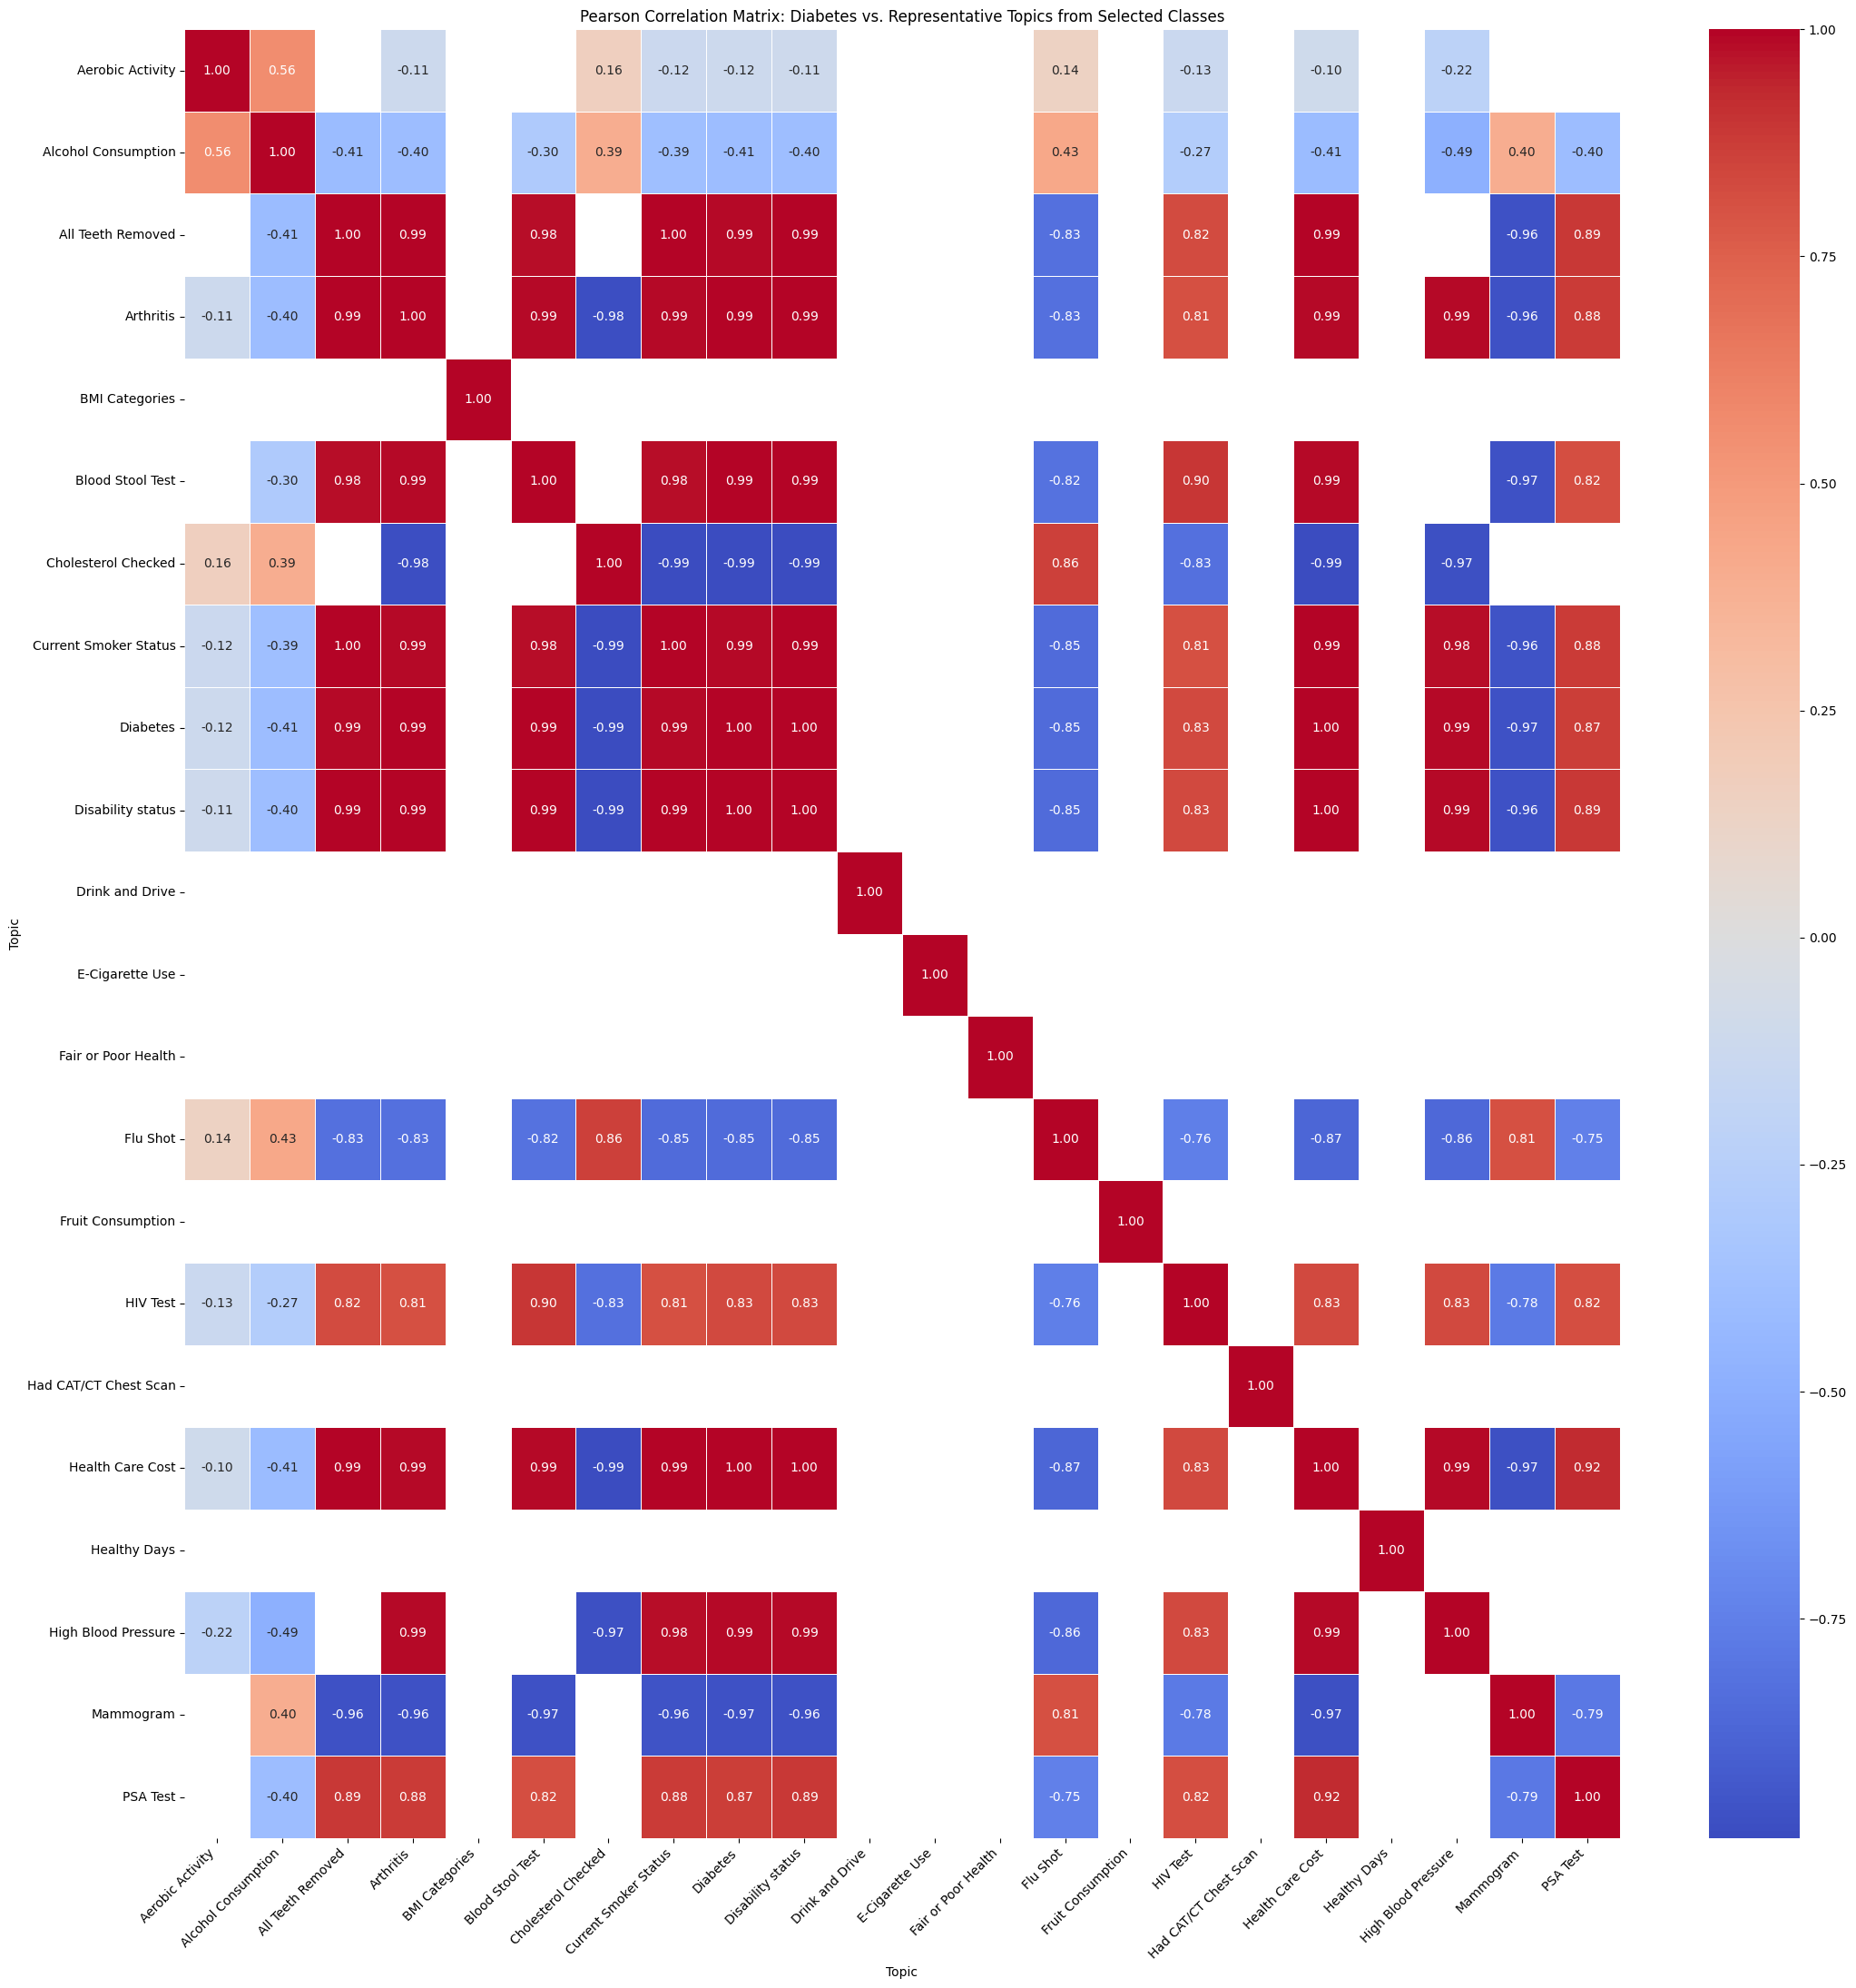

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List of classes provided by the user
user_classes_for_correlation = [
    'Colorectal Cancer Screening', 'Chronic Health Indicators', 'Health Status',
    'HIV-AIDS', 'Immunization', 'Demographics', 'Oral Health',
    'Overweight and Obesity (BMI)', 'Physical Activity', 'Tobacco Use',
    'Alcohol Consumption', 'Cholesterol Awareness',
    'Health Care Access/Coverage', 'Hypertension Awareness', 'Injury',
    'Prostate Cancer', "Women's Health", 'Fruits and Vegetables',
    'E-Cigarette Use', 'Days of Poor Health', 'Lung Cancer Screening'
]

# Initialize list of topics for correlation analysis, starting with 'Diabetes'
correlation_topics_for_heatmap = ['Diabetes']

# Create a mapping from Class to a representative Topic within that Class
# We'll pick the first unique topic alphabetically for each class, excluding 'Diabetes'
representative_topics_map = {}
for class_name in user_classes_for_correlation:
    # Get all unique topics for the current class
    topics_in_class = df[df['Class'] == class_name]['Topic'].unique().tolist()

    # Filter out 'Diabetes' if it's in the list, as it's our central topic for comparison.
    topics_to_consider = [topic for topic in topics_in_class if topic != 'Diabetes']

    # If there are other topics, pick one (e.g., the first one alphabetically for consistency)
    if topics_to_consider:
        representative_topic = sorted(topics_to_consider)[0] # Pick first alphabetically
        if representative_topic not in correlation_topics_for_heatmap: # Avoid duplicates across classes
            correlation_topics_for_heatmap.append(representative_topic)

print(f"Selected topics for correlation with Diabetes: {correlation_topics_for_heatmap}")

# Filter the DataFrame to include only these selected topics
filtered_df_for_corr = df[df['Topic'].isin(correlation_topics_for_heatmap)].copy()

# Check if filtered_df_for_corr is empty after filtering
if filtered_df_for_corr.empty:
    print("No data available for the selected topics to perform correlation. Please check topic selections.")
else:
    # Create a pivot table to get Data_value for each topic per unique context
    # Context defined by (Year, Locationdesc, Break_Out, Break_Out_Category, Response)
    # Using pivot_table will aggregate if there are multiple entries for the same context and topic (by default takes the mean).
    # It also handles potential missing values by filling with NaN, which pivot_table.corr() will ignore.
    pivot_df = filtered_df_for_corr.pivot_table(
        index=['Year', 'Locationdesc', 'Break_Out', 'Break_Out_Category', 'Response'],
        columns='Topic',
        values='Data_value'
    )

    # Check if pivot_df has enough columns to calculate correlation
    if pivot_df.shape[1] < 2:
        print("Not enough unique topics with data to calculate a correlation matrix (need at least 2).")
    else:
        # Calculate the Pearson correlation matrix
        correlation_matrix = pivot_df.corr(method='pearson')

        # Plot the heatmap
        plt.figure(figsize=(max(8, len(correlation_topics_for_heatmap)), max(8, len(correlation_topics_for_heatmap)))) # Dynamic sizing
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Pearson Correlation Matrix: Diabetes vs. Representative Topics from Selected Classes')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

Though, the given data is good to have, the map contains a lot of blank spots, which represent NaN values. So, converting this to a table would be easier to read.

In [ ]:
display(correlation_matrix)

Topic,Aerobic Activity,Alcohol Consumption,All Teeth Removed,Arthritis,BMI Categories,Blood Stool Test,Cholesterol Checked,Current Smoker Status,Diabetes,Disability status,...,Fair or Poor Health,Flu Shot,Fruit Consumption,HIV Test,Had CAT/CT Chest Scan,Health Care Cost,Healthy Days,High Blood Pressure,Mammogram,PSA Test
Topic,,,,,,,,,,,,,,,,,,,,,
Aerobic Activity,1.000000,0.562486,NaN,-0.114061,NaN,NaN,0.161989,-0.122077,-0.119863,-0.108379,...,NaN,0.137187,NaN,-0.131027,NaN,-0.100519,NaN,-0.218569,NaN,NaN
Alcohol Consumption,0.562486,1.000000,-0.411132,-0.402671,NaN,-0.297470,0.394766,-0.389345,-0.405847,-0.397013,...,NaN,0.429385,NaN,-0.269917,NaN,-0.409053,NaN,-0.489784,0.396988,-0.401064
All Teeth Removed,NaN,-0.411132,1.000000,0.994512,NaN,0.982368,NaN,0.995597,0.991511,0.994069,...,NaN,-0.828038,NaN,0.824095,NaN,0.993742,NaN,NaN,-0.962772,0.886757
Arthritis,-0.114061,-0.402671,0.994512,1.000000,NaN,0.985981,-0.983347,0.992184,0.992381,0.993389,...,NaN,-0.826750,NaN,0.810256,NaN,0.990908,NaN,0.988029,-0.960972,0.878672
BMI Categories,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Stool Test,NaN,-0.297470,0.982368,0.985981,NaN,1.000000,NaN,0.983473,0.994750,0.993296,...,NaN,-0.819182,NaN,0.898483,NaN,0.991579,NaN,NaN,-0.965191,0.815018
Cholesterol Checked,0.161989,0.394766,NaN,-0.983347,NaN,NaN,1.000000,-0.987364,-0.991517,-0.990047,...,NaN,0.864229,NaN,-0.826479,NaN,-0.991694,NaN,-0.973182,NaN,NaN
Current Smoker Status,-0.122077,-0.389345,0.995597,0.992184,NaN,0.983473,-0.987364,1.000000,0.989413,0.993399,...,NaN,-0.847664,NaN,0.807016,NaN,0.992684,NaN,0.981867,-0.959225,0.878815
Diabetes,-0.119863,-0.405847,0.991511,0.992381,NaN,0.994750,-0.991517,0.989413,1.000000,0.996967,...,NaN,-0.850436,NaN,0.832718,NaN,0.996576,NaN,0.987965,-0.967937,0.870201


I now need to show a correlation to my chosen topic of Diabetes, so I'll make another graph that represents that.

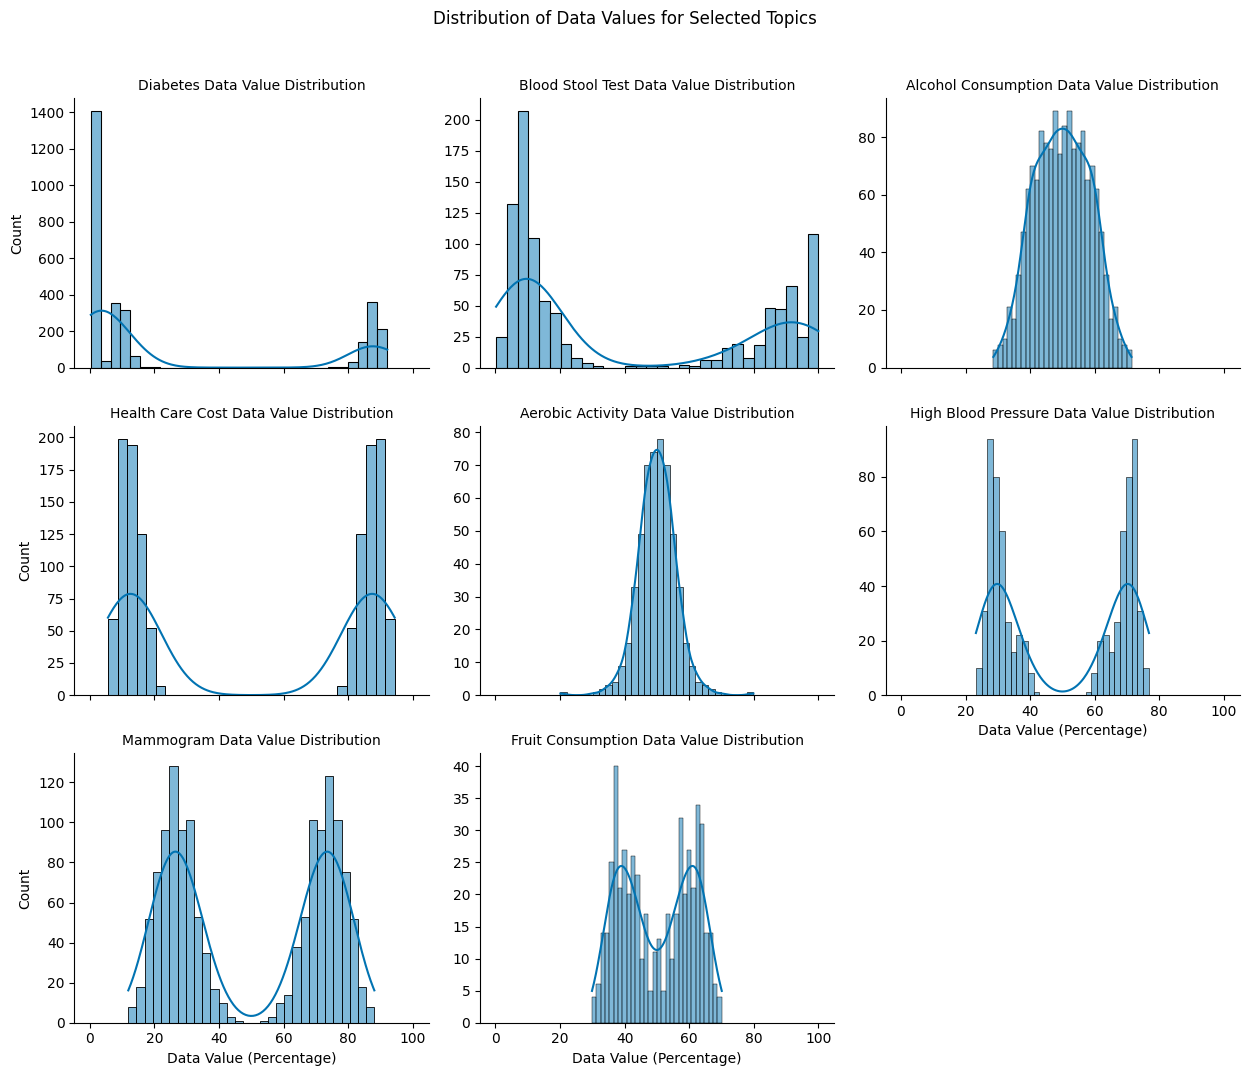

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The pivot_df created earlier contains the Data_value for each topic per unique context
# It has 'Topic' as columns and 'Data_value' as values.

# Let's select 'Diabetes' and a few other topics for histogram comparison.
# These are chosen to represent different correlation types with 'Diabetes' from the heatmap.
selected_topics_for_hist = [
    'Diabetes',
    'Blood Stool Test',  # Example of strong positive correlation with Diabetes
    'Alcohol Consumption', # Example of moderate negative correlation with Diabetes
    'Health Care Cost',   # Another relevant topic for comparison
    'Aerobic Activity',   # Adding more topics for a broader view
    'High Blood Pressure',
    'Mammogram',
    'Fruit Consumption'
]

# Ensure pivot_df is available from the previous execution
if 'pivot_df' in locals():
    # Filter pivot_df to include only the topics we want to visualize
    actual_topics_to_plot = [topic for topic in selected_topics_for_hist if topic in pivot_df.columns]

    if not actual_topics_to_plot:
        print("No valid topics found for plotting histograms from the previous correlation analysis.")
    else:
        # Extract the data for these topics
        hist_data = pivot_df[actual_topics_to_plot]

        # Melt the DataFrame to long format for easier plotting with seaborn
        hist_data_melted = hist_data.melt(var_name='Topic', value_name='Data_value')

        # Create a FacetGrid for multiple histograms
        # Adjust col_wrap to fit more plots, and height for readability
        g = sns.FacetGrid(hist_data_melted, col='Topic', col_wrap=3, sharex=True, sharey=False, height=3.5, aspect=1.2)
        g.map(sns.histplot, 'Data_value', bins=30, kde=True) # kde=True adds a kernel density estimate
        g.set_axis_labels("Data Value (Percentage)", "Count")
        g.set_titles('{col_name} Data Value Distribution') # Corrected this line
        g.fig.suptitle('Distribution of Data Values for Selected Topics', y=1.02) # Adjust suptitle position
        plt.tight_layout()
        plt.show()
else:
    print("The 'pivot_df' DataFrame was not found. Please ensure the correlation heatmap code was executed successfully.")

This Pearson correlation gives the level of dependency between variables from -1 to 1. In case of a high score close to 1, variables depend positively (they both increase). In case of a score close to -1, there is a negative dependency between variables (when one increases, another decreases). If the score is close to 0, it means that the variables are independent. According to the heatmap data, there is a near perfect positive dependency (0.99) between the Blood Stool Test and Diabetes, which indicates that wherever one variable has a high value, the other one will have a high value too. There is a moderate negative dependency (-0.41) between Alcohol Consumption and Diabetes, which means that high values in one variable will be followed by low values in another one. Also, there is a weak negative dependency (-0.30) between Alcohol Consumption and the Blood Stool Test.

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.3000,0.3265,0.3765,0.3497
1,k-NN (k=5),0.2176,0.2500,0.2824,0.2652
2,Random Forest (100 trees),0.1647,0.1647,0.1647,0.1647
3,Decision Tree (depth=4),0.4412,0.0833,0.0118,0.0206
4,Baseline (majority class),0.5000,0.0000,0.0000,0.0000


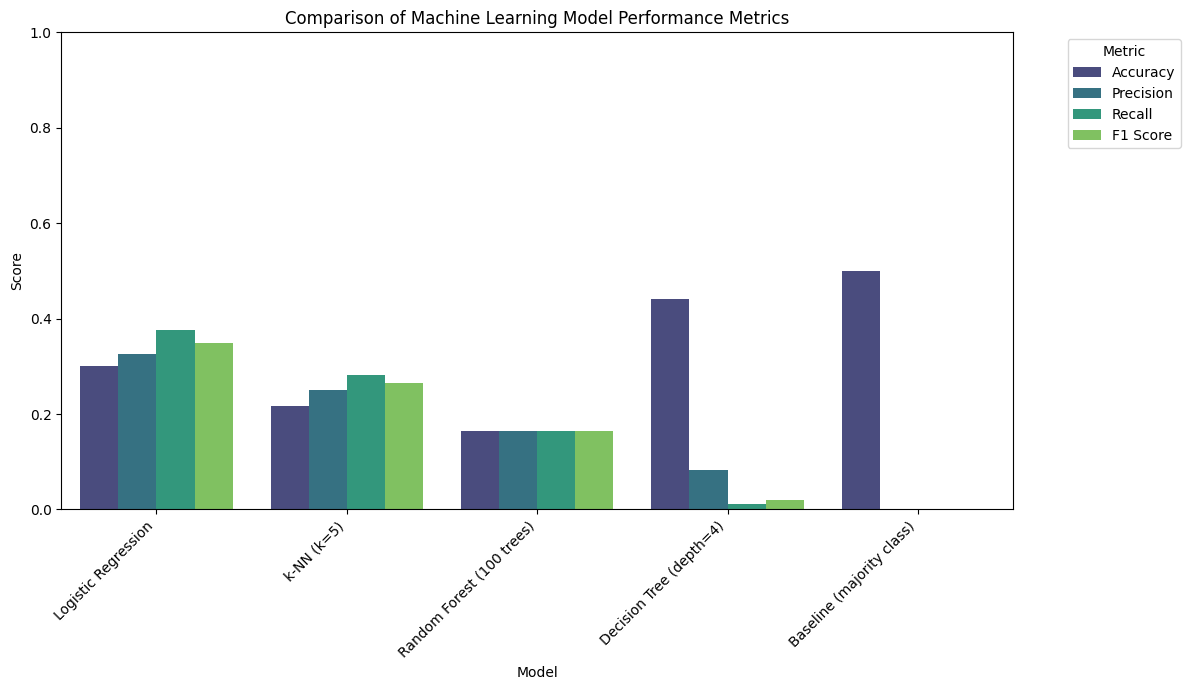

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np # Added for cleaning steps
import matplotlib.pyplot as plt # Added for plotting
import seaborn as sns # Added for plotting

# --- Start of added code to define q_df and related variables for model training ---
# This assumes 'df' DataFrame is available from previous cells (initial data loading).

# Step 2a: Scope the dataset to our research question
health_access = df[df['Class'] == 'Health Care Access/Coverage'].copy()

# Step 2b: Filter to one question, one response category we care about
target_question = 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
q_df = health_access[health_access['Question'] == target_question].copy()

# Step 2c: Drop rows with missing Data_value
q_df = q_df.dropna(subset=['Data_value'])

# Step 2d: Drop rows with unreliable sample sizes
q_df = q_df[q_df['Sample_Size'] >= 50]

# Step 2e: Drop exact duplicate rows
q_df = q_df.drop_duplicates()

# Step 2f: Fix data types
q_df['Year'] = q_df['Year'].astype(int)
q_df['Data_value'] = q_df['Data_value'].astype(float)

# 1. Build the Prediction Target
median_value = q_df['Data_value'].median()
q_df['high_burden'] = (q_df['Data_value'] > median_value).astype(int)

# 2. Features and Train/Test Split
features = ['Break_Out', 'Break_Out_Category', 'Locationabbr', 'Year']
X = pd.get_dummies(q_df[features], columns=['Break_Out', 'Break_Out_Category', 'Locationabbr'])
y = q_df['high_burden']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale the data for k-NN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# --- End of added code ---


# Define all five models in one place
models = {
    'Baseline (majority class)': (DummyClassifier(strategy='most_frequent', random_state=42), X_train, X_test),
    'Logistic Regression':       (LogisticRegression(max_iter=1000, random_state=42), X_train, X_test),
    'k-NN (k=5)':                (KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled),
    'Decision Tree (depth=4)':   (DecisionTreeClassifier(max_depth=4, random_state=42), X_train, X_test),
    'Random Forest (100 trees)': (RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42), X_train, X_test),
}

rows = []

for name, (model, X_tr, X_te) in models.items():

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1 Score': f1_score(y_test, preds, zero_division=0)
    })

results = (
    pd.DataFrame(rows)
      .sort_values("Recall", ascending=False)
      .reset_index(drop=True)
)

# Display the results table with styling
display(results.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format("{:.4f}", subset=["Accuracy", "Precision", "Recall", "F1 Score"]))

# --- Start of added code to generate a graph from the results table ---
# Melt the results DataFrame to long format for easier plotting
results_melted = results.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score']
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette='viridis'
)
plt.title('Comparison of Machine Learning Model Performance Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.tight_layout()
plt.show()
# --- End of added code ---

### 📝 Data Audit Report

> **Issue 1 — Missing values:** `Data_value`, `Confidence_limit_Low`, and `Confidence_limit_High` are each missing ___ rows. Every single one of those missing rows has a `Data_Value_Footnote` explaining why (usually: sample too small to report reliably). **This is not random missingness — it's the data source itself telling you "don't trust a number here."** That's a finding, not just a cleaning step.
>
> **Issue 2 — Sample size problem:** Some rows have very small `Sample_Size` values. A row based on ___ respondents is far less trustworthy than one based on 5,000. What's the smallest sample size in this dataset? (`df['Sample_Size'].min()`)
>
> **Issue 3 — Scope problem:** This dataset covers many topics we don't need (Depression, Veteran Status, Disability, etc). We only need the `Health Care Access/Coverage` rows — that's **9,328 rows** out of 86,481, across **8 different questions**. We're focusing on just one: the cost-barrier question. How many rows does that leave? (fill in after Step 2b)
>
> **Issue 4 — Data type:** `Year` is already stored as `int64` and `Data_value` as `float64` — good. The columns to watch are the ID columns (`ClassId`, `TopicId`, `QuestionID`, etc.) which are `object` (text) even though they look code-like. We won't need to convert those for this analysis.


## Step 2 — Clean

**Every step below needs a one-sentence justification.** This isn't busywork — a reader needs to trust that your final numbers weren't shaped by an unexplained decision.


In [ ]:
# --- Step 2a: Scope the dataset to our research question ---
# Justification: we are only investigating health care access, not every BRFSS topic
health_access = df[df['Class'] == 'Health Care Access/Coverage'].copy()
print('Rows after scoping to Health Care Access/Coverage:', health_access.shape[0])   # 9,328

# There are 8 questions in this Class -- notice two pairs of near-duplicates:
# 'Do you have one person you think of as your personal doctor...' appears in two slightly
# different wordings across survey years, and so does the "could not afford" cost-barrier question.
# This is a real BRFSS quirk: the survey wording changes over time. For now, pick ONE exact string.
print(health_access['Question'].unique())


In [ ]:
# --- Step 2b: Filter to one question, one response category we care about ---
# Justification: this question directly captures who gets LEFT OUT of care -- a cost barrier
# is a clean equity story, and the response is a simple Yes/No
target_question = 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
q_df = health_access[health_access['Question'] == target_question].copy()
print('Rows for this question:', q_df.shape[0])
q_df.head()


In [ ]:
# --- Step 2c: Drop rows with missing Data_value ---
# Justification: these are rows CDC itself flagged as unreliable (see the footnote check above) --
# we are not losing "unlucky" data here, we are removing rows the source already told us not to trust
print('Missing Data_value before:', q_df['Data_value'].isnull().sum())
q_df = q_df.dropna(subset=['Data_value'])


# --- Step 2d: Drop rows with unreliable sample sizes ---
# Justification: BRFSS analysts themselves flag very small samples as unstable — anything
# below 50 respondents is not something a policymaker should act on
q_df = q_df[q_df['Sample_Size'] >= 50]


# --- Step 2e: Drop exact duplicate rows ---
# Justification: Removing duplicate rows ensures each observation is unique and prevents biased analysis.
print('Duplicate rows:', q_df.duplicated().sum())
q_df = q_df.drop_duplicates()


# --- Step 2f: Fix data types ---
# Justification: Ensuring correct data types for 'Year' and 'Data_value' allows for proper numerical operations and consistency.
q_df['Year'] = q_df['Year'].astype(int)
q_df['Data_value'] = q_df['Data_value'].astype(float)

print('Cleaned shape:', q_df.shape)
q_df[['Year','Locationdesc','Break_Out','Break_Out_Category','Data_value','Sample_Size']].head()

### ✅ Verify


In [ ]:
assert q_df['Data_value'].isnull().sum() == 0, "Still missing Data_value"
assert q_df.duplicated().sum() == 0, "Still has duplicate rows"
assert q_df['Sample_Size'].min() >= 50, "Small samples still present"
print("All checks passed.")
q_df.describe()

### 📝 Data Limitations

> Even after cleaning, this dataset still cannot tell us ___, because it only reports percentages by group, not individual-level data. If I had to make a policy decision based on this, I would also want to know ___.


## Step 3 — Visualize

Same rules as always: labeled axes with units, a **finding-based title**, and a 2-sentence interpretation for every chart.


### Chart 1 — Bar chart: does access differ by demographic group?


In [ ]:
by_category = q_df[q_df['Break_Out_Category'] != 'Overall']
top_categories = by_category.groupby('Break_Out')['Data_value'].mean().sort_values(ascending=False).head(10)

# Check if top_categories is empty before attempting to plot
if not top_categories.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    top_categories.plot(kind='barh', ax=ax)
    ax.set_xlabel('Percentage (%)')
    ax.set_ylabel('Demographic group')
    ax.set_title('Top 10 Demographic Groups by Healthcare Access Difficulty') # Example title
    plt.tight_layout()
    plt.show()
else:
    print("No demographic groups (other than 'Overall') found in the filtered data to compare. Check `q_df['Break_Out_Category'].unique()` and previous filtering steps.")

> **Interpretation:** ___. ___.


### Chart 2 — Histogram: how spread out are the state-level rates?


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=q_df, x='Data_value', bins=25, ax=ax)
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Number of rows')
ax.set_title('___')   # replace with a finding-based title
plt.tight_layout()
plt.show()


> **Interpretation:** ___. ___.


### Chart 3 — Line chart: is this getting better or worse over time?


In [ ]:
by_year = q_df[q_df['Break_Out_Category'] == 'Overall'].groupby('Year')['Data_value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=by_year, x='Year', y='Data_value', marker='o', ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('___')   # replace with a finding-based title
plt.tight_layout()
plt.show()


> **Interpretation:** ___. ___.

**Push further — challenge an assumption:** did you expect this line to be improving steadily? Does the actual trend support or contradict that assumption?


### Chart 4 — Box plot: how much does this vary state to state?


In [ ]:
top_states = q_df[q_df['Break_Out_Category'] == 'Overall'].groupby('Locationdesc')['Data_value'].mean()
states_to_show = top_states.sort_values().index[:5].tolist() + top_states.sort_values().index[-5:].tolist()
subset = q_df[(q_df['Break_Out_Category'] == 'Overall') & (q_df['Locationdesc'].isin(states_to_show))]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=subset, x='Locationdesc', y='Data_value', ax=ax)
ax.set_xlabel('State')
ax.set_ylabel('Percentage (%)')
ax.set_title('___')   # replace with a finding-based title
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


> **Interpretation:** ___. ___.


## Step 4 — Story

### 📝 Data Brief (150 words)

Write this for a **city council member with no data background**. Plain language, no chart references, no code. State your 3 most important findings.

> ___


## 🎯 HCD Design Sprint #2 — Data Problem Statement

> **Our investigation asks:** ___
>
> **The dataset we are using is:** CDC BRFSS (`d2rk-yvas`), collected annually via phone survey, one row per (question × demographic subgroup × state × year)
>
> **The key variable we are analyzing is:** `Data_value` — the percentage of a subgroup who said Yes, they needed to see a doctor in the past 12 months but couldn't because of cost, ranging from ___% to ___%
>
> **Our investigation matters because:** ___ — without understanding this gap, ___ will continue to face ___.
>
> **We define a meaningful finding as:** ___


---
## Moving to HCD Phase: PROTOTYPE

You've defined the problem. Now you'll build a **prediction prototype**: given a demographic group, state, and year, can a model predict whether that group faces *above-average* difficulty accessing health care? This is the beginning of Week 4 — we're getting a head start because your dataset is ready for it.

**Why this matters:** a model like this could help a health department flag which populations to prioritize for outreach — *if* it's fair and accurate enough to trust.


## Step 5 — Build the Prediction Target

We'll label each row as **high burden** (1) if its access-difficulty rate is above the overall median, and **low burden** (0) if it's below. The median is a defensible, explainable cutoff — not an arbitrary one.


In [ ]:
median_value = q_df['Data_value'].median()
q_df['high_burden'] = (q_df['Data_value'] > median_value).astype(int)

print(f'Median rate: {median_value:.1f}%')
print(q_df['high_burden'].value_counts())
print(q_df['high_burden'].value_counts(normalize=True).round(2))


**Quick check:** is the split close to 50/50? If one class is much bigger than the other, remember — a model can get high accuracy just by always guessing the majority class, without learning anything.


## Step 6 — Features and Train/Test Split

**Features (X):** the information the model is allowed to use to make a prediction.
**Label (y):** the thing we're trying to predict — `high_burden`.

We are **deliberately leaving `Data_value` itself out of the features** — using it would be cheating, since that's literally what we built the label from.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['Break_Out', 'Break_Out_Category', 'Locationabbr', 'Year']
X = pd.get_dummies(q_df[features], columns=['Break_Out', 'Break_Out_Category', 'Locationabbr'])
y = q_df['high_burden']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0], '  Test rows:', X_test.shape[0])
print('Number of features after one-hot encoding:', X_train.shape[1])

# k-NN is distance-based, so scaling matters — Logistic Regression and Decision Trees don't need it,
# but scaling doesn't hurt them either
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 7 — The Baseline: What You Have to Beat

Before trying any real model, always build the simplest possible one. If your real model can't beat this, it isn't learning anything useful.


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print('Baseline accuracy (always guess the majority class):', round(accuracy_score(y_test, baseline_pred), 3))
print(classification_report(y_test, baseline_pred, zero_division=0))
print(confusion_matrix(y_test, baseline_pred))


> **Interpretation:** the baseline gets ___% accuracy just by never actually looking at the data. Any real model we build needs to clearly beat this — otherwise it isn't worth using.


## Step 8 — Model 1: Logistic Regression

**Concept:** Logistic Regression estimates the *probability* that a row is "high burden," based on a weighted combination of its features. It's the standard first model for yes/no predictions because it's simple, fast, and easy to explain to a policymaker.


In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print('Logistic Regression accuracy:', round(accuracy_score(y_test, logreg_pred), 3))
print(classification_report(y_test, logreg_pred, zero_division=0))
print(confusion_matrix(y_test, logreg_pred))


### 🔧 Tuning hints — Logistic Regression

Try these one at a time and re-run the cell above. Write down what changes.

- **`class_weight='balanced'`** — add this parameter if your baseline showed the classes are unequal in size. It tells the model to pay more attention to the smaller class instead of ignoring it.
- **`C=0.1` or `C=10`** — this controls how closely the model fits the training data. Lower `C` = simpler, more cautious model. Higher `C` = more flexible, but risk of overfitting. Try both and compare accuracy on the *test* set, not the training set.

> **Which setting worked best for this dataset, and why do you think that is?** ___


## Step 9 — Model 2: k-Nearest Neighbors

**Concept:** k-NN predicts a new row's label by looking at its `k` most similar rows in the training data and taking a majority vote. "Similar" is measured as distance — which is exactly why we scaled the features first.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print('k-NN (k=5) accuracy:', round(accuracy_score(y_test, knn_pred), 3))
print(classification_report(y_test, knn_pred, zero_division=0))
print(confusion_matrix(y_test, knn_pred))

### 🔧 Tuning hints — k-Nearest Neighbors

- **Try `n_neighbors=3`** — a small `k` follows the training data very closely (can be noisy/overfit).
- **Try `n_neighbors=15`** — a large `k` smooths things out (can miss real patterns/underfit).
- Run a quick loop to find the best `k` instead of guessing one at a time:

In [ ]:
for k in [3, 5, 7, 9, 11, 15, 21]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f'k={k}: accuracy={acc:.3f}')


> **Which `k` gave the best test accuracy? Does a bigger `k` always mean a better model?** ___


## Step 10 — Model 3: Decision Tree

**Concept:** A Decision Tree asks a series of yes/no questions about the features (e.g., "Is `Break_Out_Category` = Income?") to sort rows into `high_burden` or not. Its biggest advantage: you can actually *look at* the questions it asks — it's not a black box.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

print('Decision Tree (depth=4) accuracy:', round(accuracy_score(y_test, tree_pred), 3))
print(classification_report(y_test, tree_pred, zero_division=0))
print(confusion_matrix(y_test, tree_pred))

In [ ]:
# See the actual questions the tree is asking — this is what makes trees explainable
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree, max_depth=2, feature_names=X.columns, class_names=['low_burden','high_burden'],
          filled=True, fontsize=8, ax=ax)
plt.show()


### 🔧 Tuning hints — Decision Tree

- **`max_depth=2`** — a very shallow tree. Simple to explain, but probably too simple to be accurate.
- **`max_depth=10`** — a much deeper tree. More accurate on training data, but watch the test accuracy — a tree that's too deep starts memorizing instead of learning general patterns (overfitting).
- Compare train accuracy vs. test accuracy at each depth — a big gap between them is the warning sign of overfitting:

In [ ]:
for depth in [2, 3, 4, 6, 8, 10, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f'depth={depth}: train={train_acc:.3f}  test={test_acc:.3f}')

> **At what depth does train accuracy start pulling far ahead of test accuracy? What does that tell you?** ___


## Step 11 — Compare All Models

Accuracy alone can be misleading — remember the baseline. For this problem, think about which error is worse:

- **False negative** (model says "low burden" but the group actually struggles to access care) → the group gets missed by outreach. **This is the dangerous error here.**
- **False positive** (model says "high burden" but the group is actually fine) → some wasted outreach resources, but nobody goes without help.

That means **recall for the `high_burden` class** matters more than raw accuracy for this investigation.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Define every model in one place ---
models = {
    'Baseline (majority class)': (DummyClassifier(strategy='most_frequent', random_state=42), X_train, X_test),
    'Logistic Regression':       (LogisticRegression(max_iter=1000, random_state=42), X_train, X_test),
    'k-NN (k=5)':                (KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled),
    'Decision Tree (depth=4)':   (DecisionTreeClassifier(max_depth=4, random_state=42), X_train, X_test),
    'Random Forest (100 trees)': (RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42), X_train, X_test),
}
rows = []

for name, (model, X_tr, X_te) in models.items():

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1 Score': f1_score(y_test, preds, zero_division=0)
    })

results = (
    pd.DataFrame(rows)
      .sort_values("Recall", ascending=False)
      .reset_index(drop=True)
)

In [ ]:
results.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format("{:.4f}", subset=["Accuracy", "Precision", "Recall", "F1 Score"])

### 📝 Model Recommendation

> I recommend **___** for this application because **___** matters most here, given that a false negative means **___** and a false positive means **___**.


## Step 12 — Fairness Check

Overall accuracy can hide unfairness. A model can look great on average while consistently failing one specific group. Let's check your recommended model's **recall**, broken out by `Break_Out_Category`.


In [ ]:
# Rebuild a small test-set dataframe so we can group results by demographic category
test_info = q_df.loc[X_test.index, ['Break_Out_Category']].copy()
test_info['actual'] = y_test.values
test_info['predicted'] = logreg_pred   # swap this for knn_pred or tree_pred to check a different model

fairness_table = test_info.groupby('Break_Out_Category').apply(
    lambda g: pd.Series({
        'n_rows': len(g),
        'recall': recall_score(g['actual'], g['predicted'], zero_division=0),
        'accuracy': accuracy_score(g['actual'], g['predicted']),
    })
).round(3)

fairness_table


### 📝 Fairness Reflection

> **Which `Break_Out_Category` group has the lowest recall — meaning the model misses that group's high-burden cases most often?** ___
>
> **If this model were actually used to decide who gets outreach resources, who would be harmed by that gap?** ___
>
> **What would you change about the model, the features, or the target definition to close that gap?** ___


## End-to-End Recap

You just completed the full data science + HCD pipeline on one real dataset:

**Empathize/Define** → Assessed → Cleaned → Visualized → Told the story → Wrote a formal Problem Statement
**Prototype** → Built a baseline → Trained 3 models → Compared them → Checked fairness across groups

**For your STEAM Fair exhibit, you now have:**
- [ ] A Data Audit Report and documented cleaning pipeline
- [ ] 4 publication-quality visualizations with finding-based titles
- [ ] A 150-word Data Brief
- [ ] A formal Data Problem Statement
- [ ] A model comparison table with a justified recommendation
- [ ] A fairness analysis identifying who your model serves worst

**Still to refine before the Fair:** correlation/regression evidence (Week 3), a full written policy recommendation addressed to a real institution, and your live demo script.


## 📓 Data Journal — Exit Ticket

1. **What dataset or technique did I work with today?**
2. **What pattern or anomaly surprised me?**
3. **Who is represented in this data — and who is invisible?**
4. **My model's biggest blind spot is ___. If I only had time to fix one thing about my analysis, it would be ___.**
